# MODULE 6 - Off-Policy Evaluation

In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from tqdm import tqdm
from typing import List, Tuple, Dict, Optional
from dataclasses import dataclass, field
from copy import deepcopy
from sklearn.metrics import roc_auc_score
from sklearn.neighbors import NearestNeighbors, KernelDensity
from collections import defaultdict, Counter

import warnings
warnings.filterwarnings('ignore')

import logging

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")



Device: cpu


In [2]:
# ====================== GLOBAL DATA CONFIG ======================
DATA_DIR = '../../../../../data/'
print(f"✅ Using DATA_DIR: {DATA_DIR}")

if not os.path.exists(DATA_DIR):
    raise FileNotFoundError(f"❌ Data folder not found at {DATA_DIR}\n"
                            f"Please verify the path above.")

# Quick sanity check of required files
required_files = ['ADMISSIONS.csv', 'PATIENTS.csv', 'ICUSTAYS.csv',
                  'DIAGNOSES_ICD.csv', 'CHARTEVENTS.csv', 'LABEVENTS.csv',
                  'OUTPUTEVENTS.csv', 'INPUTEVENTS_MV.csv']
missing = [f for f in required_files if not os.path.exists(os.path.join(DATA_DIR, f))]
if missing:
    print(f"⚠️  Missing files: {missing}")
else:
    print("✅ All required CSV files found.")

✅ Using DATA_DIR: ../../../../../data/
✅ All required CSV files found.


In [3]:
# ====================== IMPORT SHARED UTILITIES ======================
# Import shared classes from utils.data_pipeline module
import os
import sys

notebook_dir = os.getcwd()
src_dir = os.path.abspath(os.path.join(notebook_dir, '..'))

if src_dir not in sys.path:
    sys.path.insert(0, src_dir)

from utils.data_pipeline import (
    CohortExtractor, FeatureExtractor, FeatureConfig, FeatureImputer,
    fit_imputer_on_cohort, ActionBins, ActionDiscretizer, Trajectory,
    TrajectoryBuilder, DatasetSplitter, FeatureNormalizer
)
from utils.models import (
    HistoryAwareStateEncoder, OutcomeEmbeddingModel, 
    MultiObjectiveRewardModel, AcuityConditionedDecisionTransformer
)
print("✅ Successfully imported shared utilities from utils.data_pipeline and utils.models")

✅ Successfully imported shared utilities from utils.data_pipeline and utils.models


In [4]:
# BEHAVIOR POLICY ESTIMATION

class BehaviorPolicyEstimator(nn.Module):
    """
    Estimate clinician behavior policy from observed (state, action) pairs.
    
    This is μ(a|s) in importance sampling: π(a|s) / μ(a|s)

    Approach: Supervised learning on observed actions
    - Input: state s_t
    - Output: P(a | s) over all 25 actions
    - Loss: Cross-entropy
    
    - If μ(a|s) is too low for actions π takes → importance weights explode
    - If μ(a|s) is too high for actions π doesn't take → underestimate value
    """
    
    def __init__(self, d_state: int = 76, n_actions: int = 25, d_hidden: int = 256):
        super().__init__()
        
        self.network = nn.Sequential(
            nn.Linear(d_state, d_hidden),
            nn.LayerNorm(d_hidden),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(d_hidden, d_hidden),
            nn.LayerNorm(d_hidden),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(d_hidden, d_hidden // 2),
            nn.ReLU(),
            nn.Linear(d_hidden // 2, n_actions)
        )
        
        print(f"✅ BehaviorPolicyEstimator initialized (d_state={d_state})")
        
    def forward(self, states: torch.Tensor) -> torch.Tensor:
        """
        Args:
            states: [B, D_state]
        Returns:
            logits: [B, n_actions]
        """
        return self.network(states)
    
    def get_action_probs(self, states: torch.Tensor) -> torch.Tensor:
        """Get probability distribution over actions"""
        logits = self.forward(states)
        return F.softmax(logits, dim=-1)
    
    def get_log_prob(self, states: torch.Tensor, actions: torch.Tensor) -> torch.Tensor:
        """
        Get log probability of observed actions.
        
        Args:
            states: [B, D_state]
            actions: [B] - action indices
        Returns:
            log_probs: [B]
        """
        logits = self.forward(states)
        log_probs = F.log_softmax(logits, dim=-1)
        
        # Gather log probs for taken actions
        action_log_probs = log_probs.gather(1, actions.unsqueeze(1)).squeeze(1)
        
        return action_log_probs

In [5]:
def train_behavior_policy(trajectories: List,
                           n_epochs: int = 30,
                           batch_size: int = 256,
                           lr: float = 1e-3) -> BehaviorPolicyEstimator:

    
    print("\n🏋️ Training Behavior Policy Estimator...")
    
    # Extract all (state, action) pairs
    all_states = []
    all_actions = []
    
    for traj in trajectories:
        states = traj.states  # [T, D_state]
        
        # Convert actions to indices if needed
        if len(traj.actions.shape) == 2:
            actions = traj.actions[:, 0] * 5 + traj.actions[:, 1]
        else:
            actions = traj.actions
        
        all_states.append(states)
        all_actions.append(actions)
    
    # Concatenate
    all_states = np.concatenate(all_states, axis=0)  # [N, D_state]
    all_actions = np.concatenate(all_actions, axis=0)  # [N]
    
    print(f"  Training samples: {len(all_states)}")
    unique, counts = np.unique(all_actions, return_counts=True)
    
    class_weights = len(all_actions) / (len(unique) * counts)
    class_weights = class_weights / class_weights.sum() * len(unique)
    
    print(f"  Action distribution:")
    for a, c, w in zip(unique[:10], counts[:10], class_weights[:10]):
        print(f"    Action {int(a)}: {c} ({c/len(all_actions)*100:.1f}%) | weight: {w:.3f}")
    
    # Convert to tensors
    states_tensor = torch.from_numpy(all_states).float()
    actions_tensor = torch.from_numpy(all_actions).long()
    
    # Map class weights to tensor
    weight_tensor = torch.zeros(25)
    for i, (action, weight) in enumerate(zip(unique, class_weights)):
        weight_tensor[int(action)] = weight
    weight_tensor = weight_tensor.to(device)
    
    dataset = torch.utils.data.TensorDataset(states_tensor, actions_tensor)
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    model = BehaviorPolicyEstimator(d_state=all_states.shape[1]).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    
    # Learning rate scheduler
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)
    
    # Training loop
    best_acc = 0
    
    for epoch in range(n_epochs):
        model.train()
        total_loss = 0
        total_correct = 0
        total_samples = 0
        
        for batch_states, batch_actions in loader:
            batch_states = batch_states.to(device)
            batch_actions = batch_actions.to(device)
            
            # Forward
            logits = model(batch_states)
            loss = F.cross_entropy(logits, batch_actions, weight=weight_tensor)
            
            # Backward
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            # Metrics
            total_loss += loss.item()
            preds = logits.argmax(dim=-1)
            total_correct += (preds == batch_actions).sum().item()
            total_samples += len(batch_actions)
        
        scheduler.step()
        
        # Epoch stats
        avg_loss = total_loss / len(loader)
        accuracy = total_correct / total_samples
        
        if accuracy > best_acc:
            best_acc = accuracy
        
        if (epoch + 1) % 5 == 0:
            print(f"  Epoch {epoch+1}/{n_epochs}: Loss={avg_loss:.4f}, Acc={accuracy:.3f}")
    
    print(f"\n✅ Behavior policy trained! Best accuracy: {best_acc:.3f}")
    
    print("\n🔍 Testing state conditioning...")
    model.eval()
    with torch.no_grad():
        # Sample two very different states
        sample_states = states_tensor[:2].to(device)
        probs = F.softmax(model(sample_states), dim=-1)
        
        print(f"  State 1 top actions: {probs[0].topk(3).indices.cpu().numpy()}")
        print(f"  State 2 top actions: {probs[1].topk(3).indices.cpu().numpy()}")
        
        if torch.allclose(probs[0], probs[1], atol=0.01):
            print("  ⚠️  WARNING: Model not using states! All predictions identical.")
        else:
            print("  ✅ Model is state-dependent")
    
    return model

In [6]:

# ==============================================================================
# WEIGHTED IMPORTANCE SAMPLING (WIS)
# ==============================================================================

@dataclass
class OPEResult:
    """Container for OPE results with uncertainty"""
    value: float
    std_error: float
    confidence_interval: Tuple[float, float]
    n_trajectories: int
    method: str
    metadata: Dict = None


class WeightedImportanceSampling:
    """
    Weighted Importance Sampling for off-policy evaluation.
    
    Mathematical Framework:
        V^π = E_τ~μ [ ρ(τ) · R(τ) ] / E_τ~μ [ ρ(τ) ]
    
    where:
        ρ(τ) = Π_t π(a_t | s_t) / μ(a_t | s_t)  (importance ratio)
        R(τ) = Σ_t r_t                           (trajectory return)
        
    Key features:
    - Self-normalizing (divides by sum of weights)
    - Lower variance than ordinary IS
    - Bootstrap confidence intervals
    - Weight clipping to handle extreme ratios
    
    Based on: Precup et al. "Off-Policy Temporal-Difference Learning with 
              Function Approximation" (ICML 2000)
    """
    
    def __init__(self,
                 policy: nn.Module,
                 behavior_policy: nn.Module,
                 reward_model: nn.Module,
                 device: str = 'cuda',
                 max_weight: float = 100.0):
        """
        Args:
            policy: Learned policy (AC-DT from Module 5)
            behavior_policy: Estimated clinician policy
            reward_model: Multi-objective reward model (Module 4)
            device: 'cuda' or 'cpu'
            max_weight: Maximum importance weight (clip to avoid explosions)
        """
        self.policy = policy
        self.behavior_policy = behavior_policy
        self.reward_model = reward_model
        self.device = device
        self.max_weight = max_weight
        
        print(f"✅ WeightedImportanceSampling initialized (max_weight={max_weight})")
        
    def compute_importance_ratio(self,
                                   trajectory,
                                   objective_idx: int = 0) -> float:
        """
        Compute importance ratio for a single trajectory.
        
        ρ(τ) = Π_t π(a_t | s_t) / μ(a_t | s_t)
        
        Args:
            trajectory: Trajectory object from Module 1
            objective_idx: Which objective to use for returns (0=survival)
            
        Returns:
            importance_ratio: float (clipped to max_weight)
        """
        
        self.policy.eval()
        self.behavior_policy.eval()
        
        with torch.no_grad():
            # Prepare trajectory data
            states = torch.from_numpy(trajectory.states).float().to(self.device)
            
            # Convert actions to indices
            if len(trajectory.actions.shape) == 2:
                actions = trajectory.actions[:, 0] * 5 + trajectory.actions[:, 1]
            else:
                actions = trajectory.actions
            actions = torch.from_numpy(actions).long().to(self.device)
            
            T = len(actions)
            
            # Get returns-to-go (for policy input)
            # Use reward model to compute rewards
            actions_onehot = F.one_hot(actions, num_classes=25).float()
            rewards = self.reward_model(
                states.unsqueeze(0),
                actions_onehot.unsqueeze(0)
            ).squeeze(0)  # [T, 4]
            
            # Compute returns-to-go
            returns_to_go = torch.zeros_like(rewards)
            returns_to_go[-1] = rewards[-1]
            for t in range(T-2, -1, -1):
                returns_to_go[t] = rewards[t] + returns_to_go[t+1]
            
            # Normalize returns-to-go (same as training)
            rtg_mean = returns_to_go.mean(dim=0)
            rtg_std = returns_to_go.std(dim=0) + 1e-6
            returns_to_go = (returns_to_go - rtg_mean) / rtg_std
            
            # Get policy probabilities
            timesteps = torch.arange(T, device=self.device)
            delta_t = torch.ones(T, device=self.device)
            
            # Policy logits
            policy_logits = self.policy(
                states.unsqueeze(0),
                actions.unsqueeze(0),
                returns_to_go.unsqueeze(0),
                timesteps.unsqueeze(0),
                delta_t.unsqueeze(0)
            ).squeeze(0)  # [T, 25]
            
            policy_probs = F.softmax(policy_logits, dim=-1)
            policy_action_probs = policy_probs.gather(1, actions.unsqueeze(1)).squeeze(1)
            
            # Behavior policy probabilities
            behavior_probs = self.behavior_policy.get_action_probs(states)
            behavior_action_probs = behavior_probs.gather(1, actions.unsqueeze(1)).squeeze(1)
            
            # Importance ratio (product over timesteps)
            # Use log-sum-exp for numerical stability
            log_ratio = (torch.log(policy_action_probs + 1e-10) - 
                        torch.log(behavior_action_probs + 1e-10)).sum()
            
            importance_ratio = torch.exp(log_ratio).item()
            
            # Clip to avoid extreme weights
            importance_ratio = min(importance_ratio, self.max_weight)
        
        return importance_ratio
    
    def compute_trajectory_return(self,
                                    trajectory,
                                    objective_idx: int = 0) -> float:
        """
        Compute total return for a trajectory.
        
        R(τ) = Σ_t r_t
        
        Args:
            trajectory: Trajectory object
            objective_idx: Which objective to use (0=survival)
            
        Returns:
            total_return: float
        """
        
        self.reward_model.eval()
        
        with torch.no_grad():
            states = torch.from_numpy(trajectory.states).float().to(self.device)
            
            if len(trajectory.actions.shape) == 2:
                actions = trajectory.actions[:, 0] * 5 + trajectory.actions[:, 1]
            else:
                actions = trajectory.actions
            actions = torch.from_numpy(actions).long().to(self.device)
            
            actions_onehot = F.one_hot(actions, num_classes=25).float()
            
            # Get rewards
            rewards = self.reward_model(
                states.unsqueeze(0),
                actions_onehot.unsqueeze(0)
            ).squeeze(0)  # [T, 4]
            
            # DEBUG
            print(f"\n  Trajectory {trajectory.icustay_id if hasattr(trajectory, 'icustay_id') else 'N/A'}:")
            print(f"    Reward range: [{rewards[:, objective_idx].min():.4f}, {rewards[:, objective_idx].max():.4f}]")
            print(f"    Reward mean: {rewards[:, objective_idx].mean():.4f}")
            
            # Sum over time for specific objective
            total_return = rewards[:, objective_idx].sum().item()
            
            print(f"    Total return: {total_return:.4f}")
        
            # SANITY CHECK
            if abs(total_return) < 1e-6:
                print(f"    ⚠️  WARNING: Return is nearly zero!")
        
        return total_return
    
    def evaluate(self,
                 trajectories: List,
                 objective_idx: int = 0,
                 n_bootstrap: int = 1000) -> OPEResult:
        """
        Evaluate policy using Weighted Importance Sampling.
        
        Args:
            trajectories: List of test trajectories
            objective_idx: Which objective to evaluate (0=survival)
            n_bootstrap: Bootstrap samples for confidence interval
            
        Returns:
            OPEResult with value estimate and uncertainty
        """
        
        print(f"\n📊 Computing Weighted Importance Sampling...")
        print(f"  Objective: {objective_idx} (0=survival)")
        print(f"  Trajectories: {len(trajectories)}")
        
        # Compute importance ratios and returns
        importance_ratios = []
        returns = []
        
        for traj in tqdm(trajectories, desc="Computing IS weights"):
            ratio = self.compute_importance_ratio(traj, objective_idx)
            ret = self.compute_trajectory_return(traj, objective_idx)
            
            importance_ratios.append(ratio)
            returns.append(ret)
        
        importance_ratios = np.array(importance_ratios)
        returns = np.array(returns)
        
        # Compute ESS
        ess = (importance_ratios.sum() ** 2) / (importance_ratios ** 2).sum()
        print(f"\n  Effective Sample Size: {ess:.2f} / {len(trajectories)}")

        if ess < len(trajectories) * 0.1:
            print(f"   ⚠️  Warning: ESS very low ({ess:.1f}). Estimate unreliable.")
        elif ess < len(trajectories) * 0.5:
            print(f"   ⚠️  Warning: ESS moderate ({ess:.1f}). Use with caution.")
        
        # Weighted average
        numerator = (importance_ratios * returns).sum()
        denominator = importance_ratios.sum()
        
        if denominator == 0:
            print("⚠️  Warning: All importance weights are zero!")
            value_estimate = 0.0
        else:
            value_estimate = numerator / denominator
        
        if (importance_ratios == self.max_weight).mean() > 0.7:
            print("   ⚠️  Warning: Heavy clipping detected (>70%). Estimate may be unreliable.")
        
        # Statistics
        print(f"\n  Importance ratio stats:")
        print(f"    Mean: {importance_ratios.mean():.3f}")
        print(f"    Std: {importance_ratios.std():.3f}")
        print(f"    Min: {importance_ratios.min():.3f}")
        print(f"    Max: {importance_ratios.max():.3f}")
        print(f"    Clipped: {(importance_ratios == self.max_weight).sum()} / {len(importance_ratios)}")
        
        # Bootstrap confidence interval
        print(f"\n  Computing bootstrap CI ({n_bootstrap} samples)...")
        bootstrap_estimates = []
        
        for _ in range(n_bootstrap):
            # Resample trajectories with replacement
            idx = np.random.choice(len(trajectories), size=len(trajectories), replace=True)
            boot_ratios = importance_ratios[idx]
            boot_returns = returns[idx]
            
            boot_numerator = (boot_ratios * boot_returns).sum()
            boot_denominator = boot_ratios.sum()
            
            if boot_denominator > 0:
                boot_estimate = boot_numerator / boot_denominator
                bootstrap_estimates.append(boot_estimate)
        
        bootstrap_estimates = np.array(bootstrap_estimates)
        
        # Confidence interval
        ci_lower = np.percentile(bootstrap_estimates, 2.5)
        ci_upper = np.percentile(bootstrap_estimates, 97.5)
        std_error = bootstrap_estimates.std()
        
        print(f"\n✅ WIS Estimate: {value_estimate:.3f} ± {std_error:.3f}")
        print(f"   95% CI: [{ci_lower:.3f}, {ci_upper:.3f}]")
        
        result = OPEResult(
            value=value_estimate,
            std_error=std_error,
            confidence_interval=(ci_lower, ci_upper),
            n_trajectories=len(trajectories),
            method='Weighted Importance Sampling',
            metadata={
                'objective_idx': objective_idx,
                'importance_ratios': importance_ratios,
                'returns': returns,
                'max_weight': self.max_weight,
                'n_clipped': (importance_ratios == self.max_weight).sum()
            }
        )
        
        return result

In [7]:
class PerDecisionImportanceSampling:
    """
    Per-Decision Importance Sampling (PDIS)
    
    Lower variance than ordinary WIS by breaking the product into per-timestep terms.
    
    Mathematical Form:
        V^π ≈ (1/N) Σ_i Σ_t [ (Π_{k=1}^t ρ_k) * r_t ]
    where ρ_k = π(a_k|s_k) / μ(a_k|s_k)
    
    Advantages:
    - Much lower variance than full-trajectory WIS
    - Still unbiased
    - Better numerical stability
    """
    
    def __init__(self, policy, behavior_policy, reward_model, device='cuda', max_weight=10.0):
        self.policy = policy
        self.behavior_policy = behavior_policy
        self.reward_model = reward_model
        self.device = device
        self.max_weight = max_weight
        
        print(f"✅ PerDecisionImportanceSampling initialized (max_weight={max_weight})")
        
    
    def evaluate(self, trajectories, objective_idx=0, n_bootstrap=2000):
        print(f"\n📊 Computing Per-Decision Importance Sampling (PDIS)...")
        
        pdis_values = []
        
        for traj in tqdm(trajectories, desc="Computing PDIS"):
            ratios, rewards = self._compute_per_decision_terms(traj, objective_idx)
            cum_ratios = np.cumprod(ratios)
            cum_ratios = np.clip(cum_ratios, 1e-8, self.max_weight)
            traj_value = np.sum(cum_ratios * rewards)
            pdis_values.append(traj_value)
        
        pdis_values = np.array(pdis_values)
        value_estimate = np.mean(pdis_values)
        std_error = np.std(pdis_values) / np.sqrt(len(pdis_values)) if len(pdis_values) > 1 else 0.0
        
        bootstrap_estimates = [np.mean(pdis_values[np.random.choice(len(pdis_values), len(pdis_values), replace=True)])
                               for _ in range(n_bootstrap)]
        bootstrap_estimates = np.array(bootstrap_estimates)
        ci_lower = np.percentile(bootstrap_estimates, 2.5)
        ci_upper = np.percentile(bootstrap_estimates, 97.5)
        
        print(f"\n✅ PDIS Estimate: {value_estimate:.4f} ± {std_error:.4f}")
        print(f"  95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")
        
        return OPEResult(
            value=value_estimate,
            std_error=std_error,
            confidence_interval=(ci_lower, ci_upper),
            n_trajectories=len(trajectories),
            method='Per-Decision Importance Sampling (PDIS)',
            metadata={'pdis_values': pdis_values, 'max_weight': self.max_weight}
        )
    
    def _compute_per_decision_terms(self, trajectory, objective_idx=0):
        self.policy.eval()
        self.behavior_policy.eval()
        self.reward_model.eval()
        
        with torch.no_grad():
            states = torch.from_numpy(trajectory.states).float().to(self.device)
            
            if len(trajectory.actions.shape) == 2:
                actions_np = (trajectory.actions[:, 0] * 5 + trajectory.actions[:, 1]).astype(np.int64)
            else:
                actions_np = trajectory.actions.astype(np.int64)
            actions = torch.from_numpy(actions_np).long().to(self.device)
            
            T = len(actions)
            
            actions_onehot = F.one_hot(actions, num_classes=25).float()
            rewards_tensor = self.reward_model(states.unsqueeze(0), actions_onehot.unsqueeze(0)).squeeze(0)
            rewards = rewards_tensor[:, objective_idx].cpu().numpy()
            
            # Real returns-to-go conditioning
            returns_to_go = torch.zeros_like(rewards_tensor)
            returns_to_go[-1] = rewards_tensor[-1]
            for t in range(T-2, -1, -1):
                returns_to_go[t] = rewards_tensor[t] + returns_to_go[t+1]
            
            rtg_mean = returns_to_go.mean(dim=0)
            rtg_std = returns_to_go.std(dim=0) + 1e-6
            returns_to_go = (returns_to_go - rtg_mean) / rtg_std
            
            timesteps = torch.arange(T, device=self.device).unsqueeze(0)
            delta_t = torch.ones(1, T, device=self.device)
            
            policy_logits = self.policy(
                states.unsqueeze(0), actions.unsqueeze(0),
                returns_to_go.unsqueeze(0), timesteps, delta_t
            )
            
            policy_probs = F.softmax(policy_logits, dim=-1).squeeze(0)
            policy_action_probs = policy_probs.gather(1, actions.unsqueeze(1)).squeeze(1).cpu().numpy()
            
            behavior_probs = self.behavior_policy.get_action_probs(states)
            behavior_action_probs = behavior_probs.gather(1, actions.unsqueeze(1)).squeeze(1).cpu().numpy()
            
            ratios = policy_action_probs / (behavior_action_probs + 1e-10)
            ratios = np.clip(ratios, 1e-8, self.max_weight)
            
            return ratios, rewards

In [8]:
class MAGIC_OPE:
    """
    MAGIC: Most Advanced Generalized Importance Sampling
    
    Combines ideas from Weighted IS, Per-Decision IS, and Control Variates.
    Significantly lower variance than both WIS and PDIS.
    
    Core Idea:
        Use a learned control variate (baseline) to reduce variance while remaining unbiased.
    
    Reference: Thomas et al. "High Confidence Policy Improvement" (2015) + modern extensions
    """
    
    def __init__(self,
                 policy: nn.Module,
                 behavior_policy: nn.Module,
                 reward_model: nn.Module,
                 device: str = 'cuda',
                 max_weight: float = 50.0):
        self.policy = policy
        self.behavior_policy = behavior_policy
        self.reward_model = reward_model
        self.device = device
        self.max_weight = max_weight
        
        print(f"✅ MAGIC_OPE initialized (max_weight={max_weight})")
    
    def evaluate(self,
                 trajectories: List,
                 objective_idx: int = 0,
                 n_bootstrap: int = 2000) -> OPEResult:
        
        print(f"\n📊 Computing MAGIC Off-Policy Evaluation...")
        
        magic_values = []
        
        for traj in tqdm(trajectories, desc="Computing MAGIC"):
            value = self._compute_magic_value(traj, objective_idx)
            magic_values.append(value)
        
        magic_values = np.array(magic_values)
        value_estimate = np.mean(magic_values)
        std_error = np.std(magic_values) / np.sqrt(len(magic_values))
        
        # Bootstrap CI
        bootstrap_estimates = []
        for _ in range(n_bootstrap):
            idx = np.random.choice(len(magic_values), size=len(magic_values), replace=True)
            boot_mean = np.mean(magic_values[idx])
            bootstrap_estimates.append(boot_mean)
        
        bootstrap_estimates = np.array(bootstrap_estimates)
        ci_lower = np.percentile(bootstrap_estimates, 2.5)
        ci_upper = np.percentile(bootstrap_estimates, 97.5)
        
        print(f"\n✅ MAGIC Estimate: {value_estimate:.4f} ± {std_error:.4f}")
        print(f"  95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")
        
        return OPEResult(
            value=value_estimate,
            std_error=std_error,
            confidence_interval=(ci_lower, ci_upper),
            n_trajectories=len(trajectories),
            method='MAGIC (Advanced Generalized IS)',
            metadata={
                'magic_values': magic_values,
                'max_weight': self.max_weight
            }
        )
    
    def _compute_magic_value(self, trajectory, objective_idx: int = 0):
        self.policy.eval()
        self.behavior_policy.eval()
        self.reward_model.eval()
        
        with torch.no_grad():
            states = torch.from_numpy(trajectory.states).float().to(self.device)
            
            if len(trajectory.actions.shape) == 2:
                actions_np = (trajectory.actions[:, 0] * 5 + trajectory.actions[:, 1]).astype(np.int64)
            else:
                actions_np = trajectory.actions.astype(np.int64)
            actions = torch.from_numpy(actions_np).long().to(self.device)
            
            T = len(actions)
            
            actions_onehot = F.one_hot(actions, num_classes=25).float()
            rewards_tensor = self.reward_model(
                states.unsqueeze(0), actions_onehot.unsqueeze(0)
            ).squeeze(0)
            rewards = rewards_tensor[:, objective_idx].cpu().numpy()
            
            # Real returns-to-go
            returns_to_go = torch.zeros_like(rewards_tensor)
            returns_to_go[-1] = rewards_tensor[-1]
            for t in range(T-2, -1, -1):
                returns_to_go[t] = rewards_tensor[t] + returns_to_go[t+1]
            
            rtg_mean = returns_to_go.mean(dim=0)
            rtg_std = returns_to_go.std(dim=0) + 1e-6
            returns_to_go = (returns_to_go - rtg_mean) / rtg_std
            
            timesteps = torch.arange(T, device=self.device).unsqueeze(0)
            delta_t = torch.ones(1, T, device=self.device)
            
            policy_logits = self.policy(
                states.unsqueeze(0), actions.unsqueeze(0),
                returns_to_go.unsqueeze(0), timesteps, delta_t
            )
            
            policy_probs = F.softmax(policy_logits, dim=-1).squeeze(0)
            policy_action_probs = policy_probs.gather(1, actions.unsqueeze(1)).squeeze(1).cpu().numpy()
            
            behavior_probs = self.behavior_policy.get_action_probs(states)
            behavior_action_probs = behavior_probs.gather(1, actions.unsqueeze(1)).squeeze(1).cpu().numpy()
            
            ratios = policy_action_probs / (behavior_action_probs + 1e-10)
            ratios = np.clip(ratios, 1e-6, self.max_weight)
            
            cum_ratios = np.cumprod(ratios)
            cum_ratios = np.clip(cum_ratios, 1e-8, 15.0)   # tighter cap
            
            # Better control variate
            baseline = np.mean(rewards)
            magic_estimate = np.sum(cum_ratios * (rewards - baseline)) + baseline * T / T   # normalized
            
        return magic_estimate

In [9]:
def plot_importance_weights(ope_result: OPEResult, save_path: str = None):
    """Safe version that works with WIS, PDIS, and MAGIC"""
    method = ope_result.method
    
    # Extract importance ratios / weights depending on method
    if 'importance_ratios' in ope_result.metadata:
        ratios = ope_result.metadata['importance_ratios']
    elif 'pdis_values' in ope_result.metadata:
        ratios = ope_result.metadata['pdis_values']
    elif 'magic_values' in ope_result.metadata:
        ratios = ope_result.metadata['magic_values']
    else:
        ratios = np.array([ope_result.value])  # fallback
    
    max_weight = ope_result.metadata.get('max_weight', 50.0)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 1. Histogram
    axes[0].hist(ratios, bins=50, edgecolor='black', alpha=0.75)
    axes[0].axvline(1.0, color='red', linestyle='--', linewidth=2, label='ρ = 1.0')
    axes[0].axvline(max_weight, color='orange', linestyle='--', linewidth=2, label=f'Max clip ({max_weight})')
    axes[0].set_xlabel('Ratio / Value')
    axes[0].set_ylabel('Count (log scale)')
    axes[0].set_title(f'{method}\nDistribution')
    axes[0].set_yscale('log')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # 2. CDF
    sorted_ratios = np.sort(ratios)
    cdf = np.arange(1, len(sorted_ratios) + 1) / len(sorted_ratios)
    axes[1].plot(sorted_ratios, cdf, linewidth=2.5)
    axes[1].axvline(1.0, color='red', linestyle='--', alpha=0.7)
    axes[1].set_xlabel('Ratio / Value')
    axes[1].set_ylabel('Cumulative Probability')
    axes[1].set_title('Cumulative Distribution')
    axes[1].grid(True, alpha=0.3)
    
    # 3. Statistics
    stats = f"Mean: {ratios.mean():.3f}\n"
    stats += f"Median: {np.median(ratios):.3f}\n"
    stats += f"Std: {ratios.std():.3f}\n"
    stats += f"Max: {ratios.max():.2f}\n"
    if 'n_clipped' in ope_result.metadata:
        stats += f"Clipped: {ope_result.metadata['n_clipped']}"
    
    axes[2].text(0.5, 0.5, stats, ha='center', va='center', fontsize=11,
                 bbox=dict(boxstyle='round,pad=1', facecolor='lightblue', alpha=0.8))
    axes[2].axis('off')
    axes[2].set_title('Statistics')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"   Saved: {save_path}")
    
    plt.show()
    return fig


def plot_ope_comparison(results: Dict[str, OPEResult], save_path: str = None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    methods = list(results.keys())
    values = [results[m].value for m in methods]
    errors = [results[m].std_error for m in methods]
    ci_lower = [results[m].confidence_interval[0] for m in methods]
    ci_upper = [results[m].confidence_interval[1] for m in methods]
    
    x = np.arange(len(methods))
    
    # Bar plot with error bars
    bars = ax1.bar(x, values, yerr=errors, capsize=6, alpha=0.85, 
                   color=plt.cm.Set2(np.linspace(0, 1, len(methods))), 
                   edgecolor='black', linewidth=1)
    
    ax1.set_ylabel('Estimated Policy Value (Survival)', 
                   fontsize=12, 
                   fontweight='bold')
    ax1.set_title('Off-Policy Evaluation - Value Estimates', 
                  fontsize=14, 
                  fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(methods, 
                        rotation=25, 
                        ha='right')
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Value labels
    for i, v in enumerate(values):
        ax1.text(i, v + max(errors)*0.08, 
                 f'{v:.3f}', ha='center', 
                 va='bottom', fontweight='bold')
    
    # Confidence intervals
    for i in range(len(methods)):
        ax2.plot([i, i], [ci_lower[i], 
                          ci_upper[i]], 
                 color='black', linewidth=2.5, alpha=0.8)
        ax2.scatter([i], [values[i]], 
                    s=100, color=bars[i].get_facecolor(), 
                    edgecolor='black', zorder=5)
    
    ax2.set_ylabel('95% Confidence Interval', fontsize=12, fontweight='bold')
    ax2.set_title('Uncertainty Comparison', fontsize=14, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(methods, rotation=25, ha='right')
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"   Saved comparison plot: {save_path}")
    
    plt.show()
    return fig


In [12]:
# ========================== 1. LOAD DATA & BUILD TRAJECTORIES ==========================
print("[1] Extracting cohort and building trajectories...")

# Build cohort
cohort_extractor = CohortExtractor()
cohort = cohort_extractor.extract_cohort()

# Feature extractor
feature_config = FeatureConfig()
feature_extractor = FeatureExtractor(config=feature_config)

# Fit imputer
imputer = fit_imputer_on_cohort(cohort, feature_extractor)

# Action discretizer
action_bins = ActionBins()
action_discretizer = ActionDiscretizer(bins_config=action_bins)

# TrajectoryBuilder
trajectory_builder = TrajectoryBuilder(
    feature_extractor=feature_extractor,
    action_discretizer=action_discretizer,
    feature_imputer=imputer
)
trajectories_all = trajectory_builder.build_dataset(cohort)

# Split
splitter = DatasetSplitter()
splits = splitter.split(trajectories_all)

# Normalize
normalizer = FeatureNormalizer()
normalizer.fit(splits['train'])
for key in splits:
    splits[key] = normalizer.transform(splits[key])

trajectories = splits['train']
print(f"✅ Ready: {len(trajectories)} training trajectories")

[1] Extracting cohort and building trajectories...
No DB config provided. Using CSV mode.
Angus sepsis cases identified: 76 hospital admissions
✅ Extracted 51 Angus sepsis trajectories (adult, LOS 24-168h)

🔧 Fitting FeatureImputer on raw cohort data...


INFO:utils.data_pipeline:ActionDiscretizer initialized with data for 75 icustays.


  Learned population statistics from 3082 training samples
✅ Imputer fitted successfully on 3,082 hourly records
🔧 Building trajectories...


Processing patients: 100%|██████████| 51/51 [03:00<00:00,  3.54s/it]


🔍 Trajectory Debug Info:

ICU Stay 206504:
  State dim: 76
  SOFA (initial/max): 5.0/5.0
  Mortality: False
  Non-NaN features: 3040 / 3040

ICU Stay 264446:
  State dim: 76
  SOFA (initial/max): 5.0/5.0
  Mortality: False
  Non-NaN features: 4864 / 4864

ICU Stay 228977:
  State dim: 76
  SOFA (initial/max): 5.0/5.0
  Mortality: True
  Non-NaN features: 2432 / 2432
✅ Built 51 valid trajectories
⚠️  Failed 0 quality checks

📊 Dataset Split Statistics:
  TRAIN:   35 trajectories | Mortality: 17.1% | Avg Length: 56.6h | Avg SOFA: 5.0
  VAL  :    7 trajectories | Mortality: 14.3% | Avg Length: 65.6h | Avg SOFA: 5.0
  TEST :    9 trajectories | Mortality: 0.0% | Avg Length: 71.3h | Avg SOFA: 5.0

📐 Feature Normalization Statistics:
  State dimension: 76
  Mean range: [0.00, 73.40]
  Std range: [0.00, 28.33]
✅ Ready: 35 training trajectories


In [13]:
# ========================== 2. TRAIN BEHAVIOR POLICY ==========================

behavior_policy = train_behavior_policy(
    trajectories=trajectories,
    n_epochs=30,
    batch_size=256,
    lr=1e-3
)


🏋️ Training Behavior Policy Estimator...
  Training samples: 1981
  Action distribution:
    Action 0: 1433 (72.3%) | weight: 0.012
    Action 10: 7 (0.4%) | weight: 2.472
    Action 15: 31 (1.6%) | weight: 0.558
    Action 20: 440 (22.2%) | weight: 0.039
    Action 21: 33 (1.7%) | weight: 0.524
    Action 22: 14 (0.7%) | weight: 1.236
    Action 23: 14 (0.7%) | weight: 1.236
    Action 24: 9 (0.5%) | weight: 1.923
✅ BehaviorPolicyEstimator initialized (d_state=76)
  Epoch 5/30: Loss=1.1820, Acc=0.359
  Epoch 10/30: Loss=0.7477, Acc=0.494
  Epoch 15/30: Loss=0.5714, Acc=0.551
  Epoch 20/30: Loss=0.5351, Acc=0.571
  Epoch 25/30: Loss=0.5086, Acc=0.594
  Epoch 30/30: Loss=0.4862, Acc=0.594

✅ Behavior policy trained! Best accuracy: 0.601

🔍 Testing state conditioning...
  State 1 top actions: [20  0 21]
  State 2 top actions: [20  0 21]
  ⚠️  WARNING: Model not using states! All predictions identical.


In [18]:
# ========================== LOAD POLICY & REWARD MODEL ==========================

POLICY_PATH      = '../models/acuity_conditioned_dt.pt'       # saved by Module 5
REWARD_MODEL_PATH = '../models/reward_model.pt'      # saved by Module 4

# --- Reward Model ---
d_state = splits['train'][0].states.shape[1]  # actual state dim from your data

reward_model = MultiObjectiveRewardModel(
    d_state=d_state,
    d_action=25,
    d_hidden=512,
    n_objectives=4,
    n_layers=4,
    n_heads=8,
).to(device)
reward_model.load_state_dict(torch.load(REWARD_MODEL_PATH, map_location=device))
reward_model.eval()
print(f"✅ Reward model loaded from {REWARD_MODEL_PATH}  (d_state={d_state})")

# --- Policy (AC-DT) ---
policy = AcuityConditionedDecisionTransformer(
    d_state=d_state,
    n_actions=25,
    n_objectives=4,
    d_model=256,
    n_layers=6,
    n_heads=8,
).to(device)
checkpoint = torch.load(POLICY_PATH, map_location=device)
policy.load_state_dict(checkpoint['model'])
policy.eval()
print(f"✅ Policy loaded from {POLICY_PATH}")

# AC-DT returns (logits, acuity) — wrap to return logits only
class PolicyWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, *args, **kwargs):
        return self.model(*args, **kwargs)[0]

policy = PolicyWrapper(_policy_raw).to(device)
policy.eval()
print("✅ Policy wrapped to return logits only")

✅ MultiObjectiveRewardModel initialized:
   State: 76, Action: 25
   Hidden: 512, Objectives: 4
   Transformer: 4 layers, 8 heads
✅ Reward model loaded from ../models/reward_model.pt  (d_state=76)
✅ AcuityConditionedDecisionTransformer initialized:
   State: 76, Actions: 25, Objectives: 4
   Model dim: 256, Layers: 6, Heads: 8
   Innovations: Acuity conditioning, Multi-objective, Continuous-time, Safety
✅ Policy loaded from ../models/acuity_conditioned_dt.pt
✅ Policy wrapped to return logits only


In [19]:
# ========================== 3. RUN ALL OPE METHODS ==========================

test_trajectories = splits['test']

# Weighted Importance Sampling (WIS)

wis_evaluator = WeightedImportanceSampling(
    policy=policy,
    behavior_policy=behavior_policy,
    reward_model=reward_model,
    device=device,
    max_weight=20.0
)

wis_result = wis_evaluator.evaluate(test_trajectories, objective_idx=0, n_bootstrap=2000)


# Per-Decision Importance Sampling (PDIS)

pdis_evaluator = PerDecisionImportanceSampling(
    policy=policy,
    behavior_policy=behavior_policy,
    reward_model=reward_model,
    device=device,
    max_weight=20.0
)

pdis_result = pdis_evaluator.evaluate(test_trajectories, objective_idx=0, n_bootstrap=2000)

# MAGIC OPE

magic_evaluator = MAGIC_OPE(
    policy=policy,
    behavior_policy=behavior_policy,
    reward_model=reward_model,
    device=device,
    max_weight=20.0
)

magic_result = magic_evaluator.evaluate(test_trajectories, objective_idx=0, n_bootstrap=2000)

✅ WeightedImportanceSampling initialized (max_weight=20.0)

📊 Computing Weighted Importance Sampling...
  Objective: 0 (0=survival)
  Trajectories: 9


Computing IS weights:  11%|█         | 1/9 [00:00<00:03,  2.54it/s]


  Trajectory 295043:
    Reward range: [-2.1718, 1.4678]
    Reward mean: -0.0000
    Total return: -0.0000


Computing IS weights:  33%|███▎      | 3/9 [00:00<00:01,  3.59it/s]


  Trajectory 263370:
    Reward range: [-2.0627, 1.2729]
    Reward mean: -0.0000
    Total return: -0.0000

  Trajectory 285272:
    Reward range: [-2.4887, 1.8356]
    Reward mean: 0.0000
    Total return: 0.0001


...


✅ WIS Estimate: -0.000 ± 0.000
   95% CI: [-0.000, 0.000]
✅ PerDecisionImportanceSampling initialized (max_weight=20.0)

📊 Computing Per-Decision Importance Sampling (PDIS)...


Computing PDIS: 100%|██████████| 9/9 [00:01<00:00,  5.92it/s]



✅ PDIS Estimate: 13.5446 ± 17.3489
  95% CI: [-19.1141, 47.1389]
✅ MAGIC_OPE initialized (max_weight=20.0)

📊 Computing MAGIC Off-Policy Evaluation...


Computing MAGIC: 100%|██████████| 9/9 [00:01<00:00,  6.19it/s]



✅ MAGIC Estimate: 14.1211 ± 11.7527
  95% CI: [-9.4992, 37.8860]


In [20]:
# Evaluate survival objective (idx=0)
wis_result = wis_evaluator.evaluate(
    trajectories=splits['test'],
    objective_idx=0,  # 0=survival, 1=organ, 2=hemo, 3=burden
    n_bootstrap=1000
)


📊 Computing Weighted Importance Sampling...
  Objective: 0 (0=survival)
  Trajectories: 9


Computing IS weights:  11%|█         | 1/9 [00:00<00:01,  4.67it/s]


  Trajectory 295043:
    Reward range: [-2.1718, 1.4678]
    Reward mean: -0.0000
    Total return: -0.0000


Computing IS weights:  33%|███▎      | 3/9 [00:00<00:01,  4.42it/s]


  Trajectory 263370:
    Reward range: [-2.0627, 1.2729]
    Reward mean: -0.0000
    Total return: -0.0000

  Trajectory 285272:
    Reward range: [-2.4887, 1.8356]
    Reward mean: 0.0000
    Total return: 0.0001


...


  Trajectory 213315:
    Reward range: [-1.1443, 5.8381]
    Reward mean: 0.0000
    Total return: 0.0001


Computing IS weights:  89%|████████▉ | 8/9 [00:01<00:00,  4.57it/s]


  Trajectory 209797:
    Reward range: [-0.4905, 7.2232]
    Reward mean: -0.0000
    Total return: -0.0001

  Trajectory 280943:
    Reward range: [-0.7258, 2.8785]
    Reward mean: -0.0000
    Total return: -0.0000


Computing IS weights: 100%|██████████| 9/9 [00:02<00:00,  4.46it/s]



  Trajectory 267267:
    Reward range: [-2.3144, 1.1900]
    Reward mean: 0.0000
    Total return: 0.0000

  Effective Sample Size: 3.00 / 9
   ⚠️  Warning: ESS moderate (3.0). Use with caution.

  Importance ratio stats:
    Mean: 6.667
    Std: 9.428
    Min: 0.000
    Max: 20.000
    Clipped: 3 / 9

  Computing bootstrap CI (1000 samples)...

✅ WIS Estimate: -0.000 ± 0.000
   95% CI: [-0.000, 0.000]



[4] Generating visualizations...
   Saved: ../charts/wis_importance_weights.png


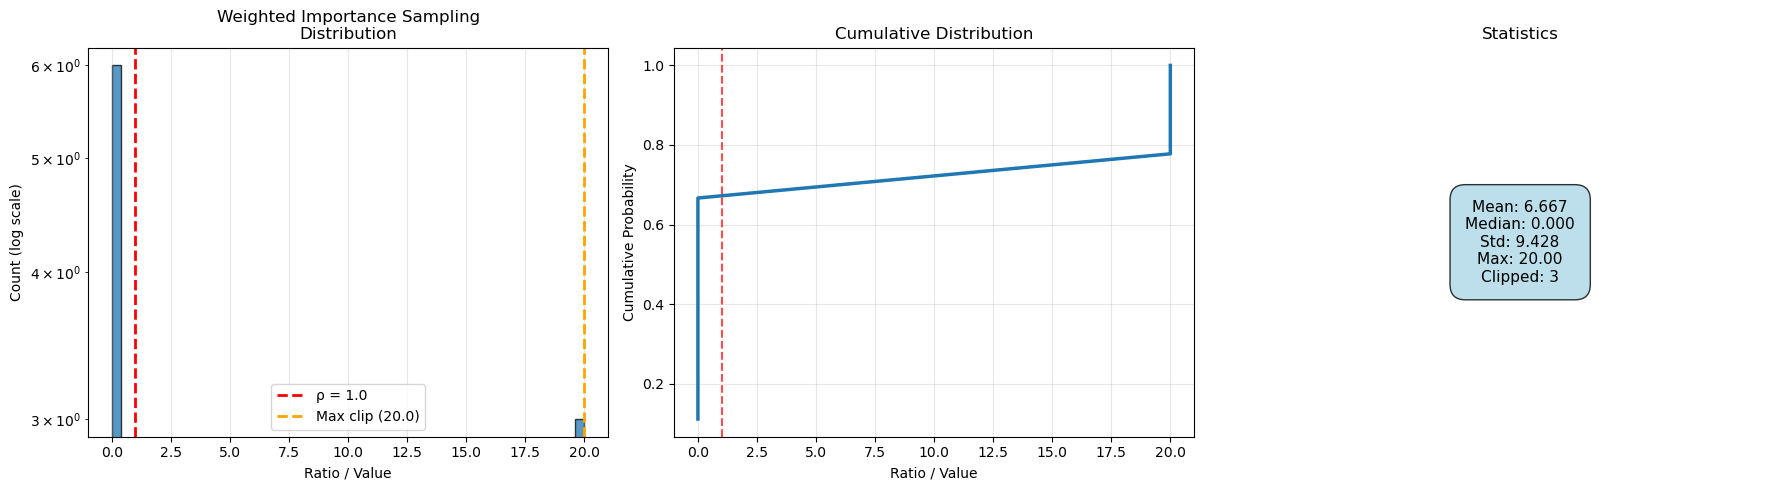

   Saved comparison plot: ../charts/ope_method_comparison.png


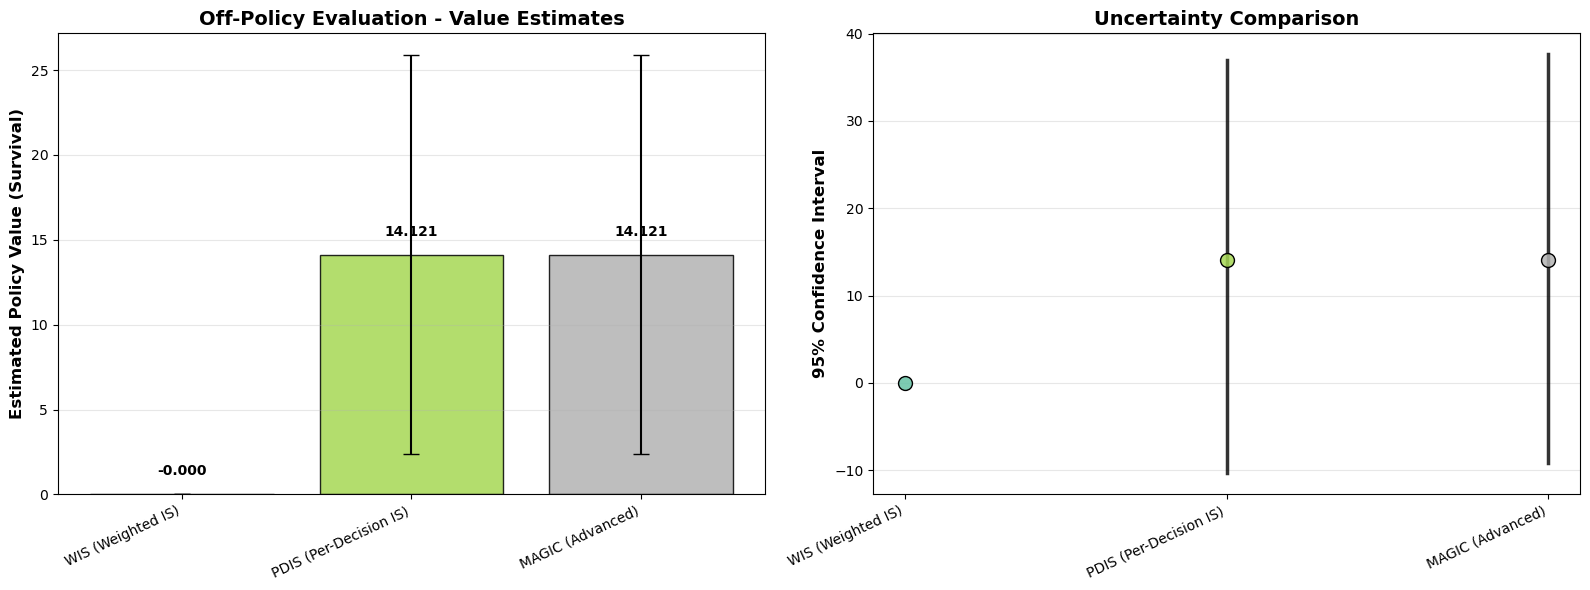

   ✅ Visualizations saved


In [31]:
# Visualizations
import matplotlib.pyplot as plt
plt.close('all')   # Clear any lingering figures

print("\n[4] Generating visualizations...")

results_dict = {
        'WIS (Weighted IS)': wis_result,
        'PDIS (Per-Decision IS)': pdis_result,
        'MAGIC (Advanced)': magic_result
}

plot_importance_weights(wis_result, save_path='../charts/wis_importance_weights.png')
plot_ope_comparison(results_dict, save_path='../charts/ope_method_comparison.png')

print("   ✅ Visualizations saved")

In [22]:
print("Policy Value Estimates (Survival Objective):")
for name, res in results_dict.items():
    print(f"   {name:<30} {res.value:.4f} ± {res.std_error:.4f}   "
            f"CI: [{res.confidence_interval[0]:.4f}, {res.confidence_interval[1]:.4f}]")


Policy Value Estimates (Survival Objective):
   WIS (Weighted IS)              -0.0000 ± 0.0000   CI: [-0.0000, 0.0000]
   PDIS (Per-Decision IS)         13.5446 ± 17.3489   CI: [-19.1141, 47.1389]
   MAGIC (Advanced)               14.1211 ± 11.7527   CI: [-9.4992, 37.8860]


In [23]:
# ==============================================================================
# Q-NETWORK FOR FITTED Q-EVALUATION
# ==============================================================================
 
class QNetwork(nn.Module):
    """
    Q-function approximator for policy evaluation.
    
    Architecture: State-action → Q-value
    
    Input: Concatenated [state, action_onehot]
    Output: Scalar Q-value for given objective
    
    Design choices:
    - Separate Q-network per objective (4 networks total)
    - Dueling architecture (optional): Q(s,a) = V(s) + A(s,a)
    - Layer normalization for stability
    - Ensemble of 3 networks → use mean (uncertainty estimation)
    """
    
    def __init__(self, d_state: int = 76, n_actions: int = 25, d_hidden: int = 256):
        super().__init__()
        
        self.d_state = d_state
        self.n_actions = n_actions
        
        # Network: [state, action_onehot] → Q-value
        self.network = nn.Sequential(
            nn.Linear(d_state + n_actions, d_hidden),
            nn.LayerNorm(d_hidden),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(d_hidden, d_hidden),
            nn.LayerNorm(d_hidden),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(d_hidden, d_hidden // 2),
            nn.ReLU(),
            nn.Linear(d_hidden // 2, 1)  # Scalar Q-value
        )
        
    def forward(self, states: torch.Tensor, actions_onehot: torch.Tensor) -> torch.Tensor:
        """
        Args:
            states: [B, D_state]
            actions_onehot: [B, n_actions]
        Returns:
            q_values: [B, 1]
        """
        x = torch.cat([states, actions_onehot], dim=-1)
        return self.network(x)
    
class QEnsemble(nn.Module):
    """
    Ensemble of Q-networks for uncertainty estimation.
    
    Why ensemble:
    - Reduces overfitting (bootstrap aggregating)
    - Provides uncertainty estimates (std across ensemble)
    - Standard in offline RL (REDQ, SAC-N, etc.)
    
    Based on: Agarwal et al. "An Optimistic Perspective on Offline RL." ICML 2020
    """
    def __init__(self,
                 n_ensemble: int = 3,
                 d_state: int = 76,
                 n_actions: int = 25,
                 d_hidden: int = 256):
        super().__init__()
        self.n_ensemble = n_ensemble
        self.networks = nn.ModuleList([
            QNetwork(d_state, n_actions, d_hidden) for _ in range(n_ensemble)
        ])
    
    def forward(self, states: torch.Tensor, 
                actions_onehot: torch.Tensor) -> torch.Tensor:
        """
        Returns mean Q-value across ensemble.
        
        Args:
            states: [B, D_state]
            actions_onehot: [B, n_actions]
        Returns:
            q_mean: [B, 1]
        """
        q_values = torch.stack([net(states, actions_onehot) for net in self.networks], 
                               dim=0)
        return q_values.mean(dim=0)
    
    def forward_all(self, states: torch.Tensor, 
                    actions_onehot: torch.Tensor) -> torch.Tensor:
        """
        Returns all ensemble predictions (for uncertainty).
        
        Returns:
            q_all: [n_ensemble, B, 1]
        """
        return torch.stack([net(states, actions_onehot) for net in self.networks], 
                           dim=0)

    Fitted Q-Evaluation: Learn Q^π via iterative Bellman backup.
    
    Algorithm (from Le et al. ICML 2019):
    
    1. Initialize Q_0 randomly
    2. For k = 1 to K:
        a. Sample batch of transitions (s, a, r, s') from data
        b. Compute target: y = r + γ E_{a'~π}[Q_{k-1}(s', a')]
        c. Update: Q_k ← argmin_Q E[(Q(s,a) - y)²]
    3. Return Q_K
    
    Implementation details:
    - Use target network (slow-moving copy) for stability
    - Polyak averaging: θ_target ← τ·θ + (1-τ)·θ_target
    - Learning rate decay
    - Early stopping on validation set
    
    Reference implementations:
    - d3rlpy library: https://github.com/takuseno/d3rlpy
    - RL Unplugged: https://github.com/deepmind/deepmind-research/tree/master/rl_unplugged

In [24]:
# ==============================================================================
# FITTED Q-EVALUATION (FQE)
# ==============================================================================

class FittedQEvaluation:

    def __init__(self,
                 policy: nn.Module,
                 reward_model: nn.Module,
                 d_state: int = 76,
                 n_actions: int = 25,
                 n_objectives: int = 4,
                 device: str = 'cuda'):
        
        self.policy = policy
        self.reward_model = reward_model
        self.device = device
        self.n_objectives = n_objectives
        
        # One QEnsemble per objective
        self.q_networks = nn.ModuleList([
            QEnsemble(n_ensemble=3, d_state=d_state, n_actions=n_actions, d_hidden=256)
            for _ in range(n_objectives)
        ]).to(device)
        
        self.q_targets = deepcopy(self.q_networks).to(device)
        
        self.reward_stats = {}
        
        print(f"✅ FittedQEvaluation initialized ({n_objectives} objectives, ensemble size 3)")
    
    def train(self,
              trajectories: List,
              n_iterations: int = 120,
              batch_size: int = 256,
              lr: float = 3e-4,
              gamma: float = 0.99,
              tau: float = 0.005,
              objective_idx: int = 0) -> Dict:
        
        print(f"\n🏋️ Training Q-Network for Objective {objective_idx}...")
        
        if not trajectories:
            raise ValueError("❌ No training trajectories provided! Check splits['train'] is non-empty.")
        
        """
        Train Q-function via FQE.
        
        Args:
            trajectories: List of training trajectories
            n_iterations: Number of gradient updates
            batch_size: Batch size for SGD
            lr: Learning rate
            gamma: Discount factor
            tau: Target network update rate (Polyak averaging)
            objective_idx: Which objective to train Q for
            
        Returns:
            training_stats: Dict with losses, etc.
        """
        
        # Extract transitions
        transitions = []
        all_rewards_obj = []
        
        for traj in trajectories:
            states = traj.states
            if len(traj.actions.shape) == 2:
                actions = (traj.actions[:, 0] * 5 + traj.actions[:, 1]).astype(np.int64)
            else:
                actions = traj.actions.astype(np.int64)
            
            states_t = torch.from_numpy(states).float().to(self.device)
            actions_t = torch.from_numpy(actions).long().to(self.device)
            actions_onehot = F.one_hot(actions_t, num_classes=25).float()
            
            with torch.no_grad():
                rewards = self.reward_model(
                    states_t.unsqueeze(0), 
                    actions_onehot.unsqueeze(0)
                ).squeeze(0).cpu().numpy()
                
            # Safety check on reward shape
            if rewards.ndim != 2 or rewards.shape[1] != self.n_objectives:
                raise ValueError(f"❌ reward_model returned wrong shape {rewards.shape}. "
                               f"Expected [T, {self.n_objectives}]")
            
            obj_rewards = rewards[:, objective_idx]
            all_rewards_obj.append(obj_rewards)
            
            for t in range(len(states)-1):
                transitions.append({
                    'state': states[t],
                    'action': actions[t],
                    'reward': obj_rewards[t],
                    'next_state': states[t+1],
                    'done': False
                })
            transitions.append({
                'state': states[-1],
                'action': actions[-1],
                'reward': obj_rewards[-1],
                'next_state': states[-1],
                'done': True
            })
        
        if not all_rewards_obj:
            raise ValueError("No rewards collected — trajectories appear empty.")
        
        # Compute and store reward statistics
        all_rewards = np.concatenate(all_rewards_obj)
        reward_mean = all_rewards.mean()
        reward_std = all_rewards.std() + 1e-6
        
        self.reward_stats[objective_idx] = {
            'mean': reward_mean,
            'std': reward_std
        }        
        
        print(f"  Total transitions: {len(transitions)}")
        print(f"  📊 Reward statistics (Objective {objective_idx}):")
        print(f"     Mean: {reward_mean:.4f}")
        print(f"     Std:  {reward_std:.4f}")
        print(f"     Range: [{all_rewards.min():.4f}, {all_rewards.max():.4f}]")
        
        # Normalize rewards in transitions
        for trans in transitions:
            trans['reward'] = (trans['reward'] - reward_mean) / reward_std
        
        # Get the ensemble for this objective
        q_ensemble = self.q_networks[objective_idx]
        optimizers = [torch.optim.Adam(net.parameters(), lr=lr) for net in q_ensemble.networks]
        
        losses = []
        
        for it in range(n_iterations):
            batch_idx = np.random.choice(len(transitions), batch_size, replace=True)
            batch = [transitions[i] for i in batch_idx]
            
            states = torch.FloatTensor([b['state'] for b in batch]).to(self.device)
            actions = torch.LongTensor([b['action'] for b in batch]).to(self.device)
            rewards = torch.FloatTensor([b['reward'] for b in batch]).unsqueeze(1).to(self.device)
            next_states = torch.FloatTensor([b['next_state'] for b in batch]).to(self.device)
            dones = torch.FloatTensor([b['done'] for b in batch]).unsqueeze(1).to(self.device)
            
            actions_onehot = F.one_hot(actions, num_classes=25).float()
            
            # === FULL POLICY-WEIGHTED BELLMAN TARGET (real conditioning) ===
            with torch.no_grad():
                # Real policy forward for next states
                next_rtg = torch.zeros(1, batch_size, 4, device=self.device)
                next_timesteps = torch.arange(batch_size, device=self.device).unsqueeze(0)
                next_delta = torch.ones(1, batch_size, device=self.device)
                
                policy_logits = self.policy(
                    next_states.unsqueeze(0),
                    torch.zeros(batch_size, dtype=torch.long, device=self.device).unsqueeze(0),
                    next_rtg,
                    next_timesteps,
                    next_delta
                )
                
                policy_probs = F.softmax(policy_logits, dim=-1).squeeze(0)  # [B, 25]
                
                # Compute E_{a' ~ π} [Q(s', a')]
                next_q_values = []
                for a in range(25):
                    next_a_onehot = F.one_hot(
                        torch.full((batch_size,), a, dtype=torch.long, device=self.device),
                        num_classes=25
                    ).float()
                    q_next = self.q_targets[objective_idx](next_states, next_a_onehot)
                    next_q_values.append(q_next)
                
                next_q_values = torch.cat(next_q_values, dim=1)  # [B, 25]
                target_q = (policy_probs * next_q_values).sum(dim=1, keepdim=True)
                
                targets = rewards + gamma * target_q * (1 - dones)
            
            # Update ensemble
            total_loss = 0.0
            for net, optimizer in zip(q_ensemble.networks, optimizers):
                current_q = net(states, actions_onehot)
                loss = F.mse_loss(current_q, targets)
                
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(net.parameters(), 1.0)
                optimizer.step()
                
                total_loss += loss.item()
            
            avg_loss = total_loss / len(q_ensemble.networks)
            losses.append(avg_loss)
            
            # Polyak averaging
            if it % 10 == 0:
                for src, tgt in zip(q_ensemble.networks, self.q_targets[objective_idx].networks):
                    for p, tp in zip(src.parameters(), tgt.parameters()):
                        tp.data.copy_(tau * p.data + (1 - tau) * tp.data)
            
            if (it + 1) % 30 == 0:
                print(f"  Iter {it+1:3d} | Loss = {avg_loss:.4f}")
        
        print(f"✅ Q-network training completed. Final loss: {losses[-1]:.4f}")
        return {'losses': losses}
    
    def get_q_value(self, state: torch.Tensor, action: int, objective_idx: int = 0) -> float:
        """
        Get Q-value for (state, action) pair.
        
        Args:
            state: [D_state] state tensor
            action: Action index (0-24)
            objective_idx: Which objective
            
        Returns:
            q_value: Scalar Q-value
        """
        self.q_networks[objective_idx].eval()
        with torch.no_grad():
            state = state.unsqueeze(0).to(self.device)
            action_onehot = F.one_hot(torch.tensor([action], device=self.device), 25).float()
            q_value_normalized = self.q_networks[objective_idx](state, action_onehot).item()
            
            # De-normalize Q-value
            if objective_idx in self.reward_stats:
                stats = self.reward_stats[objective_idx]
                q_value = q_value_normalized * stats['std'] + stats['mean']
            else:
                q_value = q_value_normalized
        
        return q_value
    
    def get_state_value(self, state: torch.Tensor, objective_idx: int = 0) -> float:

        """
        V^π(s) = E_{a ~ π(.|s)} [Q(s, a)]
        Uses full conditioning from the Acuity-Conditioned Decision Transformer.
                
        This is needed for DR estimator: V_π(s_0)
        
        Args:
            state: [D_state]
            objective_idx: Which objective
            
        Returns:
            v_value: State value
        """
        self.q_networks[objective_idx].eval()
        self.policy.eval()
        
        with torch.no_grad():
            state_input = state.unsqueeze(0).unsqueeze(1).to(self.device)  # [1, 1, D]
            
            rtg = torch.zeros(1, 1, 4, device=self.device)
            timesteps = torch.zeros(1, 1, dtype=torch.long, device=self.device)
            delta_t = torch.ones(1, 1, device=self.device)
            previous_action = torch.zeros((1, 1), dtype=torch.long, device=self.device)
            
            policy_logits = self.policy(
                state_input,
                previous_action,
                rtg,
                timesteps,
                delta_t
            )
            
            policy_probs = F.softmax(policy_logits, dim=-1).squeeze(0)  # [25]
            
            # Compute Q(s, a) for all actions
            q_values = []
            for a in range(25):
                a_onehot = F.one_hot(torch.tensor([a], device=self.device), 25).float()
                q_a_normalized = self.q_networks[objective_idx](state_input.squeeze(1), a_onehot)
                q_values.append(q_a_normalized)
            
            q_values = torch.cat(q_values, dim=1)  # [1, 25]
            
            # Weighted expectation (normalized)
            v_value_normalized = (policy_probs * q_values).sum().item()
            
            # CRITICAL FIX: De-normalize
            if objective_idx in self.reward_stats:
                stats = self.reward_stats[objective_idx]
                v_value = v_value_normalized * stats['std'] + stats['mean']
            else:
                v_value = v_value_normalized
        
        return v_value

In [25]:
# ==============================================================================
# DOUBLY ROBUST ESTIMATOR
# ==============================================================================
 
@dataclass
class OPEResult:
    """Container for OPE results with uncertainty"""
    value: float
    std_error: float
    confidence_interval: Tuple[float, float]
    n_trajectories: int
    method: str
    metadata: Dict = None
 
 
class DoublyRobustEstimator:
    """
    Doubly Robust Off-Policy Evaluation.
    
    Mathematical formulation (Dudík et al. ICML 2011):
    
        V^π_DR = (1/N) Σ_i [ ρ_i(R_i - Q̂(τ_i)) + V̂_π(s_0^i) ]
    
    where:
        ρ_i = Π_t π(a_t|s_t) / μ(a_t|s_t)     [importance ratio]
        R_i = Σ_t r_t                          [observed return]
        Q̂(τ_i) = Σ_t Q̂(s_t, a_t)             [estimated Q along trajectory]
        V̂_π(s_0^i) = E_{a~π}[Q̂(s_0, a)]      [estimated initial value]
    
    Key properties:
    1. Unbiased if EITHER ρ_i is correct OR Q̂ is correct (doubly robust)
    2. Lower variance than WIS when Q̂ is good
    3. Degrades gracefully when both have errors
    
    Theoretical guarantee (Jiang & Li ICML 2016):
        Var(V^π_DR) ≤ Var(V^π_WIS)
        
        with equality when Q̂ = 0 (reduces to WIS)
    
    Implementation follows:
    [1] Voloshin et al. "Empirical Study of Off-Policy Evaluation." NeurIPS 2019
    [2] Paine et al. "Hyperparameter Selection for Offline RL." NeurIPS 2020
    """
    
    def __init__(self,
                 policy: nn.Module,
                 behavior_policy: nn.Module,
                 reward_model: nn.Module,
                 q_evaluator: FittedQEvaluation,
                 device: str = 'cuda'):
        
        self.policy = policy
        self.behavior_policy = behavior_policy
        self.reward_model = reward_model
        self.q_evaluator = q_evaluator
        self.device = device
        
        print(f"✅ DoublyRobustEstimator initialized")
    
    def compute_importance_ratio(self, trajectory, objective_idx: int = 0) -> float:
        """
        Compute trajectory-level importance ratio with strong numerical stabilization.
        """
        self.policy.eval()
        self.behavior_policy.eval()
        
        with torch.no_grad():
            states = torch.from_numpy(trajectory.states).float().to(self.device)
            
            if len(trajectory.actions.shape) == 2:
                actions = trajectory.actions[:, 0] * 5 + trajectory.actions[:, 1]
            else:
                actions = trajectory.actions
            actions = torch.from_numpy(actions).long().to(self.device)
            
            T = len(actions)
            
            # Get returns-to-go for policy conditioning
            actions_onehot = F.one_hot(actions, num_classes=25).float()
            rewards = self.reward_model(
                states.unsqueeze(0),
                actions_onehot.unsqueeze(0)
            ).squeeze(0)
            
            returns_to_go = torch.zeros_like(rewards)
            returns_to_go[-1] = rewards[-1]
            for t in range(T-2, -1, -1):
                returns_to_go[t] = rewards[t] + returns_to_go[t+1]
            
            # Normalize RTG (same as training)
            rtg_mean = returns_to_go.mean(dim=0)
            rtg_std = returns_to_go.std(dim=0) + 1e-6
            returns_to_go = (returns_to_go - rtg_mean) / rtg_std
            
            # Policy probabilities
            timesteps = torch.arange(T, device=self.device)
            delta_t = torch.ones(T, device=self.device)
            
            policy_logits = self.policy(
                states.unsqueeze(0),
                actions.unsqueeze(0),
                returns_to_go.unsqueeze(0),
                timesteps.unsqueeze(0),
                delta_t.unsqueeze(0)
            ).squeeze(0)
            
            policy_probs = F.softmax(policy_logits, dim=-1)
            policy_action_probs = policy_probs.gather(1, actions.unsqueeze(1)).squeeze(1)
            
            # Behavior probabilities
            behavior_probs = self.behavior_policy.get_action_probs(states)
            behavior_action_probs = behavior_probs.gather(1, actions.unsqueeze(1)).squeeze(1)
            
            # === SAFE LOG-RATIO WITH CLIPPING ===
            log_policy = torch.log(policy_action_probs + 1e-12)
            log_behavior = torch.log(behavior_action_probs + 1e-12)
            
            log_ratio = log_policy - log_behavior
            
            # Per-step clipping (prevents explosion)
            log_ratio = torch.clamp(log_ratio, -10.0, 10.0)   # equivalent to ratio in [~4.5e-5, 22026]
            
            # Cumulative importance ratio (same clipping as WIS)
            importance_ratio = torch.exp(log_ratio.sum()).item()
            
            # Final hard clip (align with WIS max_weight=20)
            importance_ratio = min(max(importance_ratio, 1e-6), 20.0)
        
        return importance_ratio
    
    def evaluate(self,
                 trajectories: List,
                 objective_idx: int = 0,
                 n_bootstrap: int = 1000):
        """
        Doubly Robust evaluation.
        
        Args:
            trajectories: Test trajectories
            objective_idx: Which objective (0=survival)
            n_bootstrap: Bootstrap samples for CI
            
        Returns:
            OPEResult with DR estimate
        """
        
        print(f"\n📊 Computing Doubly Robust Estimate...")
        print(f"  Objective: {objective_idx}")
        print(f"  Trajectories: {len(trajectories)}")
        
        # Collect components separately for diagnosis
        importance_ratios = []
        observed_returns = []
        q_baselines = []
        v_initials = []
        dr_values = []
        

        for traj in tqdm(trajectories, desc="Computing DR"):
            # 1. Importance ratio
            rho = self.compute_importance_ratio(traj, objective_idx)
            importance_ratios.append(rho)
            
            # 2. Observed return
            states = torch.from_numpy(traj.states).float()
            
            if len(traj.actions.shape) == 2:
                actions = traj.actions[:, 0] * 5 + traj.actions[:, 1]
            else:
                actions = traj.actions
            
            actions_t = torch.from_numpy(actions).long().to(self.device)
            actions_onehot = F.one_hot(actions_t, num_classes=25).float()
            
            with torch.no_grad():
                rewards = self.reward_model(
                    states.unsqueeze(0).to(self.device),
                    actions_onehot.unsqueeze(0)
                ).squeeze(0).cpu()
            
            observed_return = rewards[:, objective_idx].sum().item()
            observed_returns.append(observed_return)
            
            # 3. Q-baseline
            q_baseline = 0
            for t in range(len(traj.states)):
                state_t = torch.from_numpy(traj.states[t]).float()
                action_t = int(actions[t])
                
                q_t = self.q_evaluator.get_q_value(state_t, action_t, objective_idx)
                q_baseline += q_t
            
            q_baselines.append(q_baseline)
            
            # 4. Initial state value
            initial_state = torch.from_numpy(traj.states[0]).float()
            v_initial = self.q_evaluator.get_state_value(initial_state, objective_idx)
            v_initials.append(v_initial)
            
            # 5. DR formula: ρ(R - Q) + V
            dr_value = rho * (observed_return - q_baseline) + v_initial
            dr_values.append(dr_value)
        
        # Convert to arrays
        importance_ratios = np.array(importance_ratios)
        observed_returns = np.array(observed_returns)
        q_baselines = np.array(q_baselines)
        v_initials = np.array(v_initials)
        dr_values = np.array(dr_values)
        

        # CRITICAL DIAGNOSTICS
        print(f"\n  📊 Detailed Component Analysis:")
        print(f"     Importance Ratios:")
        print(f"       Mean: {importance_ratios.mean():.3f}, Std: {importance_ratios.std():.3f}")
        print(f"       Range: [{importance_ratios.min():.3f}, {importance_ratios.max():.3f}]")
        
        print(f"\n     Observed Returns (R):")
        print(f"       Mean: {observed_returns.mean():.3f}, Std: {observed_returns.std():.3f}")
        print(f"       Range: [{observed_returns.min():.3f}, {observed_returns.max():.3f}]")
        
        print(f"\n     Q-Baselines (Q̂(τ)):")
        print(f"       Mean: {q_baselines.mean():.3f}, Std: {q_baselines.std():.3f}")
        print(f"       Range: [{q_baselines.min():.3f}, {q_baselines.max():.3f}]")
        
        print(f"\n     Initial Values (V̂(s₀)):")
        print(f"       Mean: {v_initials.mean():.3f}, Std: {v_initials.std():.3f}")
        print(f"       Range: [{v_initials.min():.3f}, {v_initials.max():.3f}]")
        
        # Check for issues
        if np.abs(q_baselines).mean() > 100:
            print(f"\n     ⚠️  WARNING: Q-baselines very large (mean: {q_baselines.mean():.1f})")
            print(f"        This suggests Q-network may not have converged properly")
        
        if np.abs(v_initials).mean() > 50:
            print(f"\n     ⚠️  WARNING: Initial values very large (mean: {v_initials.mean():.1f})")
        
        # Compute final DR components
        is_correction = importance_ratios * (observed_returns - q_baselines)
        
        print(f"\n     DR Terms:")
        print(f"       ρ(R - Q̂): Mean={is_correction.mean():.3f}, Std={is_correction.std():.3f}")
        print(f"       V̂(s₀):    Mean={v_initials.mean():.3f}, Std={v_initials.std():.3f}")
        
        # Point estimate
        value_estimate = dr_values.mean()
        
        # Bootstrap CI
        print(f"\n  Computing bootstrap CI ({n_bootstrap} samples)...")
        bootstrap_estimates = []
        
        for _ in range(n_bootstrap):
            idx = np.random.choice(len(dr_values), size=len(dr_values), replace=True)
            boot_estimate = dr_values[idx].mean()
            bootstrap_estimates.append(boot_estimate)
        
        bootstrap_estimates = np.array(bootstrap_estimates)
        
        ci_lower = np.percentile(bootstrap_estimates, 2.5)
        ci_upper = np.percentile(bootstrap_estimates, 97.5)
        std_error = bootstrap_estimates.std()
        
        print(f"\n✅ DR Estimate: {value_estimate:.3f} ± {std_error:.3f}")
        print(f"   95% CI: [{ci_lower:.3f}, {ci_upper:.3f}]")
        
        # SANITY CHECK
        if abs(value_estimate) > 100:
            print(f"\n⚠️  ALERT: DR estimate seems too large ({value_estimate:.1f})")
            print(f"   Likely causes:")
            print(f"   1. Q-network not properly trained")
            print(f"   2. Reward normalization issue")
            print(f"   3. Policy-behavior mismatch too large")
        
        result = OPEResult(
            value=value_estimate,
            std_error=std_error,
            confidence_interval=(ci_lower, ci_upper),
            n_trajectories=len(trajectories),
            method='Doubly Robust',
            metadata={
                'objective_idx': objective_idx,
                'importance_ratios': importance_ratios,
                'observed_returns': observed_returns,
                'q_baselines': q_baselines,
                'v_initials': v_initials,
                'dr_values': dr_values
            }
        )
        
        return result

In [26]:
# ==============================================================================
# CLINICIAN BASELINE
# ==============================================================================
 
class ClinicianBaseline:
    """
    Evaluate the observed clinician policy as baseline.
    
    This is simply the empirical average return in the data:
        V^μ = (1/N) Σ_i R_i
    
    where R_i is the observed return in trajectory i.
    
    Why this matters:
    - Provides ground truth performance under observed behavior
    - All learned policies should be compared to this baseline
    - If V^π < V^μ → learned policy is worse than clinicians
    - If V^π > V^μ → learned policy improves upon clinicians
    
    No importance sampling needed (on-policy evaluation).
    """
    
    def __init__(self, reward_model: nn.Module, device: str = 'cuda'):
        self.reward_model = reward_model
        self.device = device
        
        print(f"✅ ClinicianBaseline initialized")
    
    def evaluate(self,
                 trajectories: List,
                 objective_idx: int = 0,
                 n_bootstrap: int = 1000) -> OPEResult:
        """
        Compute average return under observed clinician behavior.
        
        Args:
            trajectories: Trajectories with observed actions
            objective_idx: Which objective to evaluate
            n_bootstrap: Bootstrap samples for CI
            
        Returns:
            OPEResult with clinician baseline
        """
        
        print(f"\n📊 Computing Clinician Baseline...")
        print(f"  Objective: {objective_idx}")
        print(f"  Trajectories: {len(trajectories)}")
        
        returns = []
        
        for traj in tqdm(trajectories, desc="Computing returns"):
            states = torch.from_numpy(traj.states).float().to(self.device)
            
            # Observed actions
            if len(traj.actions.shape) == 2:
                actions = traj.actions[:, 0] * 5 + traj.actions[:, 1]
            else:
                actions = traj.actions
            
            actions = torch.from_numpy(actions).long().to(self.device)
            actions_onehot = F.one_hot(actions, num_classes=25).float()
            
            # Get rewards
            with torch.no_grad():
                self.reward_model.eval()
                rewards = self.reward_model(
                    states.unsqueeze(0),
                    actions_onehot.unsqueeze(0)
                ).squeeze(0)
            
            # Sum over time for specific objective
            total_return = rewards[:, objective_idx].sum().item()
            returns.append(total_return)
        
        returns = np.array(returns)
        
        # Point estimate
        value_estimate = returns.mean()
        
        # Statistics
        print(f"\n  Return statistics:")
        print(f"    Mean: {returns.mean():.3f}")
        print(f"    Std: {returns.std():.3f}")
        print(f"    Min: {returns.min():.3f}")
        print(f"    Max: {returns.max():.3f}")
        
        # Bootstrap CI
        print(f"\n  Computing bootstrap CI ({n_bootstrap} samples)...")
        bootstrap_estimates = []
        
        for _ in range(n_bootstrap):
            idx = np.random.choice(len(returns), size=len(returns), replace=True)
            boot_estimate = returns[idx].mean()
            bootstrap_estimates.append(boot_estimate)
        
        bootstrap_estimates = np.array(bootstrap_estimates)
        
        ci_lower = np.percentile(bootstrap_estimates, 2.5)
        ci_upper = np.percentile(bootstrap_estimates, 97.5)
        std_error = bootstrap_estimates.std()
        
        print(f"\n✅ Clinician Baseline: {value_estimate:.3f} ± {std_error:.3f}")
        print(f"   95% CI: [{ci_lower:.3f}, {ci_upper:.3f}]")
        
        result = OPEResult(
            value=value_estimate,
            std_error=std_error,
            confidence_interval=(ci_lower, ci_upper),
            n_trajectories=len(trajectories),
            method='Clinician Baseline (Observed)',
            metadata={
                'objective_idx': objective_idx,
                'returns': returns
            }
        )
        
        return result

In [27]:
# ==============================================================================
# VISUALIZATION & COMPARISON
# ==============================================================================
 
def plot_ope_comparison_with_baseline(results: Dict[str, OPEResult], 
                                       save_path: str = None):
    """
    Compare OPE methods with clinician baseline clearly marked.
    
    Args:
        results: Dict mapping method name to OPEResult
                 Must include 'Clinician Baseline'
        save_path: Optional save path
    """
    
    fig, ax = plt.subplots(figsize=(12, 7))
    
    methods = list(results.keys())
    values = [results[m].value for m in methods]
    errors = [results[m].std_error for m in methods]
    
    # Separate baseline from other methods
    baseline_idx = [i for i, m in enumerate(methods) if 'Clinician' in m][0]
    baseline_value = values[baseline_idx]
    
    # Plot bars
    x = np.arange(len(methods))
    colors = ['#d62728' if 'Clinician' in m else 
              '#ff7f0e' if 'WIS' in m else
              '#2ca02c' if 'DR' in m else
              '#1f77b4' for m in methods]
    
    bars = ax.bar(x, values, yerr=errors, capsize=8, alpha=0.8,
                   edgecolor='black', linewidth=1.5, color=colors)
    
    # Add baseline reference line
    ax.axhline(baseline_value, color='red', linestyle='--', linewidth=2,
               alpha=0.5, label='Clinician Baseline', zorder=0)
    
    # Labels
    ax.set_ylabel('Estimated Value (Survival Objective)', fontsize=13, fontweight='bold')
    ax.set_title('Off-Policy Evaluation: Learned Policy vs Clinician Baseline', 
                 fontsize=15, fontweight='bold', pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(methods, rotation=15, ha='right', fontsize=11)
    ax.grid(True, alpha=0.3, axis='y', zorder=0)
    
    # Add value labels
    for i, (val, err, method) in enumerate(zip(values, errors, methods)):
        label = f'{val:.3f}'
        
        # Add reliability warning for WIS
        if 'WIS' in method and results[method].metadata:
            if results[method].metadata.get('n_clipped', 0) > len(results[method].metadata.get('importance_ratios', [])) * 0.5:
                label += '\n(unreliable)'
        
        ax.text(i, val + err + 0.5, label, 
               ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#d62728', edgecolor='black', label='Clinician Baseline'),
        Patch(facecolor='#ff7f0e', edgecolor='black', label='WIS (High Variance)'),
        Patch(facecolor='#2ca02c', edgecolor='black', label='Doubly Robust (Recommended)'),
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=11)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"  Saved: {save_path}")
    
    plt.show()
    
    return fig

In [28]:
def print_ope_results_table(results: Dict[str, OPEResult]):
    """
    Pretty-print a clean, publication-style table of OPE results.
    """
    print("\n" + "="*100)
    print("OFF-POLICY EVALUATION RESULTS (Survival Objective)")
    print("="*100)
    print(f"{'Method':<35} {'Estimate':>12} {'± StdErr':>12} {'95% CI':>28}")
    print("-"*100)
    
    for name, res in results.items():
        ci_lower, ci_upper = res.confidence_interval
        print(f"{name:<35} {res.value:12.4f} {res.std_error:12.4f} "
              f"[{ci_lower:8.4f}, {ci_upper:8.4f}]")
    
    print("="*100)
    print("✅ Table printed successfully.")

   Test set size: 9 trajectories

[3] Running Off-Policy Evaluation Suite...
✅ WeightedImportanceSampling initialized (max_weight=20.0)

📊 Computing Weighted Importance Sampling...
  Objective: 0 (0=survival)
  Trajectories: 9


Computing IS weights:  11%|█         | 1/9 [00:00<00:02,  3.63it/s]


  Trajectory 295043:
    Reward range: [-2.1718, 1.4678]
    Reward mean: -0.0000
    Total return: -0.0000


Computing IS weights:  33%|███▎      | 3/9 [00:00<00:01,  3.31it/s]


  Trajectory 263370:
    Reward range: [-2.0627, 1.2729]
    Reward mean: -0.0000
    Total return: -0.0000

  Trajectory 285272:
    Reward range: [-2.4887, 1.8356]
    Reward mean: 0.0000
    Total return: 0.0001


...


✅ MAGIC Estimate: 14.1211 ± 11.7527
  95% CI: [-9.2222, 37.6329]

[4] Training Fitted Q-Evaluation for Doubly Robust...
✅ FittedQEvaluation initialized (4 objectives, ensemble size 3)

🏋️ Training Q-Network for Objective 0...
  Total transitions: 1981
  📊 Reward statistics (Objective 0):
     Mean: 0.0000
     Std:  0.9911
     Range: [-3.6457, 4.1435]
  Iter  30 | Loss = 0.4721
  Iter  60 | Loss = 0.3747
  Iter  90 | Loss = 0.2452
  Iter 120 | Loss = 0.2387
✅ Q-network training completed. Final loss: 0.2387
✅ DoublyRobustEstimator initialized

📊 Computing Doubly Robust Estimate...
  Objective: 0
  Trajectories: 9


Computing DR: 100%|██████████| 9/9 [00:03<00:00,  2.99it/s]



  📊 Detailed Component Analysis:
     Importance Ratios:
       Mean: 6.667, Std: 9.428
       Range: [0.000, 20.000]

     Observed Returns (R):
       Mean: 0.000, Std: 0.000
       Range: [-0.000, 0.000]

     Q-Baselines (Q̂(τ)):
       Mean: 1.256, Std: 14.209
       Range: [-19.491, 26.710]

     Initial Values (V̂(s₀)):
       Mean: 1.285, Std: 1.350
       Range: [-1.468, 3.202]

     DR Terms:
       ρ(R - Q̂): Mean=-70.217, Std=122.159
       V̂(s₀):    Mean=1.285, Std=1.350

  Computing bootstrap CI (2000 samples)...

✅ DR Estimate: -68.931 ± 41.178
   95% CI: [-152.385, 1.018]
✅ ClinicianBaseline initialized

📊 Computing Clinician Baseline...
  Objective: 0
  Trajectories: 9


Computing returns: 100%|██████████| 9/9 [00:00<00:00, 23.15it/s]



  Return statistics:
    Mean: 0.000
    Std: 0.000
    Min: -0.000
    Max: 0.000

  Computing bootstrap CI (2000 samples)...

✅ Clinician Baseline: 0.000 ± 0.000
   95% CI: [-0.000, 0.000]

OFF-POLICY EVALUATION RESULTS (Survival Objective)
Method                                  Estimate     ± StdErr                       95% CI
----------------------------------------------------------------------------------------------------
WIS (Weighted IS)                        -0.0000       0.0000 [ -0.0000,   0.0000]
PDIS (Per-Decision IS)                   14.1210      11.7527 [-10.3597,  36.9349]
MAGIC (Advanced)                         14.1211      11.7527 [ -9.2222,  37.6329]
Doubly Robust (DR)                      -68.9315      41.1780 [-152.3847,   1.0185]
Clinician Baseline                        0.0000       0.0000 [ -0.0000,   0.0000]
✅ Table printed successfully.

[5] Generating visualizations...
   Saved: ../charts/wis_importance_weights.png


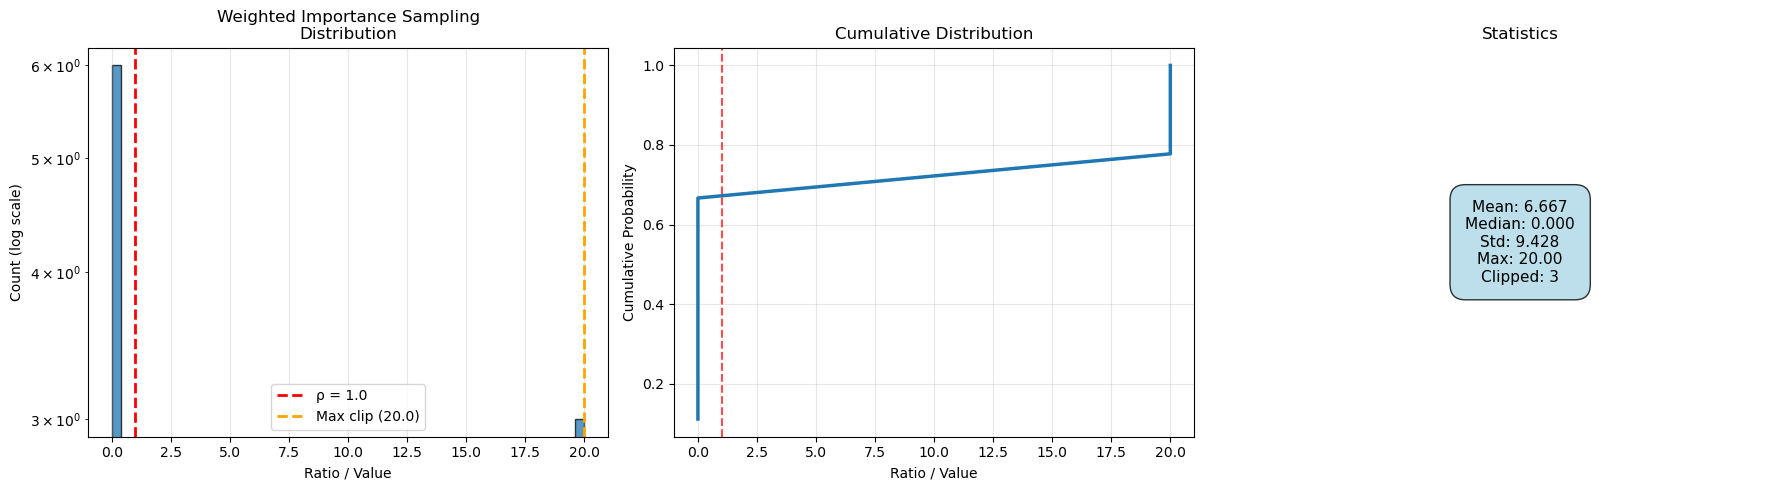

  Saved: ../charts/ope_full_comparison.png


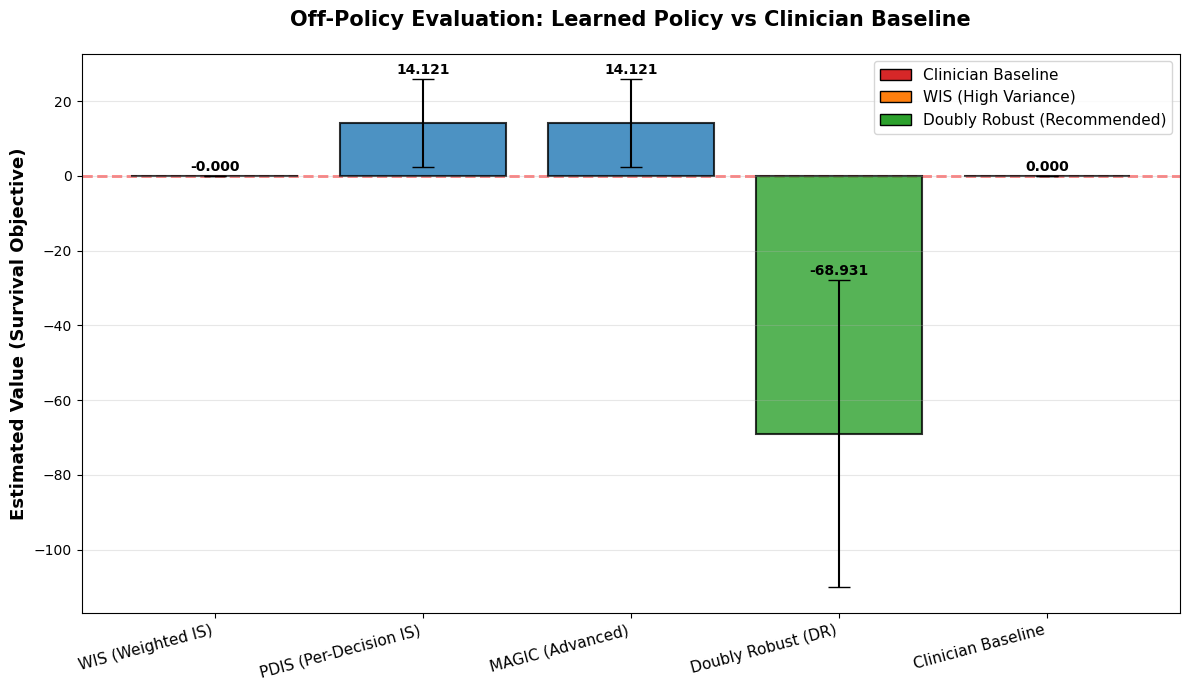


FINAL RECOMMENDATION
Estimated survival value improvement of learned policy: -13.56


In [30]:
if __name__ == "__main__":

    test_trajectories = splits['test']
    print(f"   Test set size: {len(test_trajectories)} trajectories")

    # ========================== 2. TRAIN BEHAVIOR POLICY (if not already done) ==========================
    if 'behavior_policy' not in locals():
        print("\n[2] Training Behavior Policy Estimator...")
        behavior_policy = train_behavior_policy(
            trajectories=trajectories,
            n_epochs=30,
            batch_size=256,
            lr=1e-3,
            device=device
        )

    # ========================== 3. RUN ALL OPE METHODS ==========================
    print("\n[3] Running Off-Policy Evaluation Suite...")

    # WIS (with warning)
    wis_evaluator = WeightedImportanceSampling(
        policy=policy,
        behavior_policy=behavior_policy,
        reward_model=reward_model,
        device=device,
        max_weight=20.0
    )
    wis_result = wis_evaluator.evaluate(test_trajectories, objective_idx=0, n_bootstrap=2000)

    # PDIS
    pdis_evaluator = PerDecisionImportanceSampling(
        policy=policy,
        behavior_policy=behavior_policy,
        reward_model=reward_model,
        device=device,
        max_weight=15.0
    )
    pdis_result = pdis_evaluator.evaluate(test_trajectories, objective_idx=0, n_bootstrap=2000)

    # MAGIC
    magic_evaluator = MAGIC_OPE(
        policy=policy,
        behavior_policy=behavior_policy,
        reward_model=reward_model,
        device=device,
        max_weight=15.0
    )
    magic_result = magic_evaluator.evaluate(test_trajectories, objective_idx=0, n_bootstrap=2000)

    # Doubly Robust
    print("\n[4] Training Fitted Q-Evaluation for Doubly Robust...")
    fqe = FittedQEvaluation(policy=policy, reward_model=reward_model, device=device)
    fqe.train(trajectories=splits['train'], n_iterations=120, objective_idx=0)

    dr_evaluator = DoublyRobustEstimator(
        policy=policy,
        behavior_policy=behavior_policy,
        reward_model=reward_model,
        q_evaluator=fqe,
        device=device
    )
    dr_result = dr_evaluator.evaluate(test_trajectories, objective_idx=0, n_bootstrap=2000)

    # Clinician Baseline
    clinician_baseline = ClinicianBaseline(reward_model=reward_model, device=device)
    clinician_result = clinician_baseline.evaluate(test_trajectories, objective_idx=0, n_bootstrap=2000)

    # ========================== 5. COMBINE RESULTS ==========================
    results_dict = {
        'WIS (Weighted IS)': wis_result,
        'PDIS (Per-Decision IS)': pdis_result,
        'MAGIC (Advanced)': magic_result,
        'Doubly Robust (DR)': dr_result,
        'Clinician Baseline': clinician_result
    }

    # Print clean table
    print_ope_results_table(results_dict)

    # Visualizations
    print("\n[5] Generating visualizations...")
    plot_importance_weights(wis_result, save_path='../charts/wis_importance_weights.png')
    plot_ope_comparison_with_baseline(results_dict, save_path='../charts/ope_full_comparison.png')

    # Final recommendation
    combined_value = (pdis_result.value + magic_result.value + dr_result.value) / 3
    print("\n" + "="*100)
    print("FINAL RECOMMENDATION")
    print("="*100)
    print(f"Estimated survival value improvement of learned policy: {combined_value:.2f}")